# ML

In [ ]:
import pandas as pd

train_url = "https://raw.githubusercontent.com/touXik/LLM-vs-ML-projet-nlp-/main/data/train_ml.csv"
test_url = "https://raw.githubusercontent.com/touXik/LLM-vs-ML-projet-nlp-/main/data/test_ml.csv"

In [ ]:
!pip install xgboost -q

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier


In [ ]:
train = pd.read_csv(train_url)
test  = pd.read_csv(test_url)

X_train = train.drop("Outcome", axis=1)
y_train = train["Outcome"]

X_test = test.drop("Outcome", axis=1)
y_test = test["Outcome"]

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Classes train : {y_train.value_counts().to_dict()}")

Train : (800, 8)  |  Test : (154, 8)
Classes train : {0: 400, 1: 400}


In [ ]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM":           SVC(kernel='rbf', probability=True, random_state=42),
    "XGBoost":       XGBClassifier(n_estimators=100, random_state=42,
                                  eval_metric='logloss', verbosity=0),

    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),

    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100),
    "AdaBoost": AdaBoostClassifier(n_estimators=100),

}


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("=== VALIDATION CROISÉE 5-FOLD ===\n")

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    cv_results[name] = scores
    print(f"{name}")
    print(f"  F1 par fold : {scores.round(3)}")
    print(f"  Moyenne : {scores.mean():.3f}  (+/- {scores.std():.3f})\n")

=== VALIDATION CROISÉE 5-FOLD ===

Random Forest
  F1 par fold : [0.792 0.824 0.829 0.821 0.847]
  Moyenne : 0.823  (+/- 0.018)

SVM
  F1 par fold : [0.768 0.798 0.807 0.807 0.752]
  Moyenne : 0.786  (+/- 0.022)

XGBoost
  F1 par fold : [0.782 0.812 0.805 0.802 0.826]
  Moyenne : 0.805  (+/- 0.014)

Logistic Regression
  F1 par fold : [0.699 0.758 0.758 0.778 0.747]
  Moyenne : 0.748  (+/- 0.026)

KNN
  F1 par fold : [0.767 0.777 0.81  0.821 0.798]
  Moyenne : 0.795  (+/- 0.020)

Naive Bayes
  F1 par fold : [0.699 0.735 0.781 0.744 0.697]
  Moyenne : 0.731  (+/- 0.031)

Gradient Boosting
  F1 par fold : [0.792 0.778 0.802 0.781 0.79 ]
  Moyenne : 0.789  (+/- 0.009)

AdaBoost
  F1 par fold : [0.728 0.755 0.793 0.785 0.731]
  Moyenne : 0.758  (+/- 0.027)



In [ ]:
results = {}

for name, model in models.items():
    # Entraînement sur tout le train
    model.fit(X_train, y_train)

    # Prédictions
    y_pred      = model.predict(X_test)

    if hasattr(model, "predict_proba"):
      y_pred_prob = model.predict_proba(X_test)[:, 1]
    else:
      y_pred_prob = None

    # Métriques
    results[name] = {
        "Accuracy"  : accuracy_score(y_test, y_pred),
        "Precision" : precision_score(y_test, y_pred),
        "Recall"    : recall_score(y_test, y_pred),
        "F1"        : f1_score(y_test, y_pred),
        "AUC"       : roc_auc_score(y_test, y_pred_prob),
        "y_pred"    : y_pred,
        "y_prob"    : y_pred_prob
    }

# Affichage tableau
df_results = pd.DataFrame(results).T[["Accuracy", "Precision", "Recall", "F1", "AUC"]]
print("=== RÉSULTATS SUR LE TEST ===\n")
print(df_results.round(3))

=== RÉSULTATS SUR LE TEST ===

                     Accuracy Precision    Recall        F1       AUC
Random Forest        0.733766       0.6  0.722222  0.655462    0.8075
SVM                  0.707792  0.558442  0.796296  0.656489  0.786667
XGBoost              0.733766  0.606557  0.685185  0.643478  0.817407
Logistic Regression   0.74026  0.612903  0.703704  0.655172   0.82037
KNN                  0.655844  0.506849  0.685185  0.582677    0.7025
Naive Bayes          0.720779   0.58209  0.722222  0.644628  0.783333
Gradient Boosting     0.74026  0.606061  0.740741  0.666667  0.822593
AdaBoost             0.753247  0.637931  0.685185  0.660714  0.836296


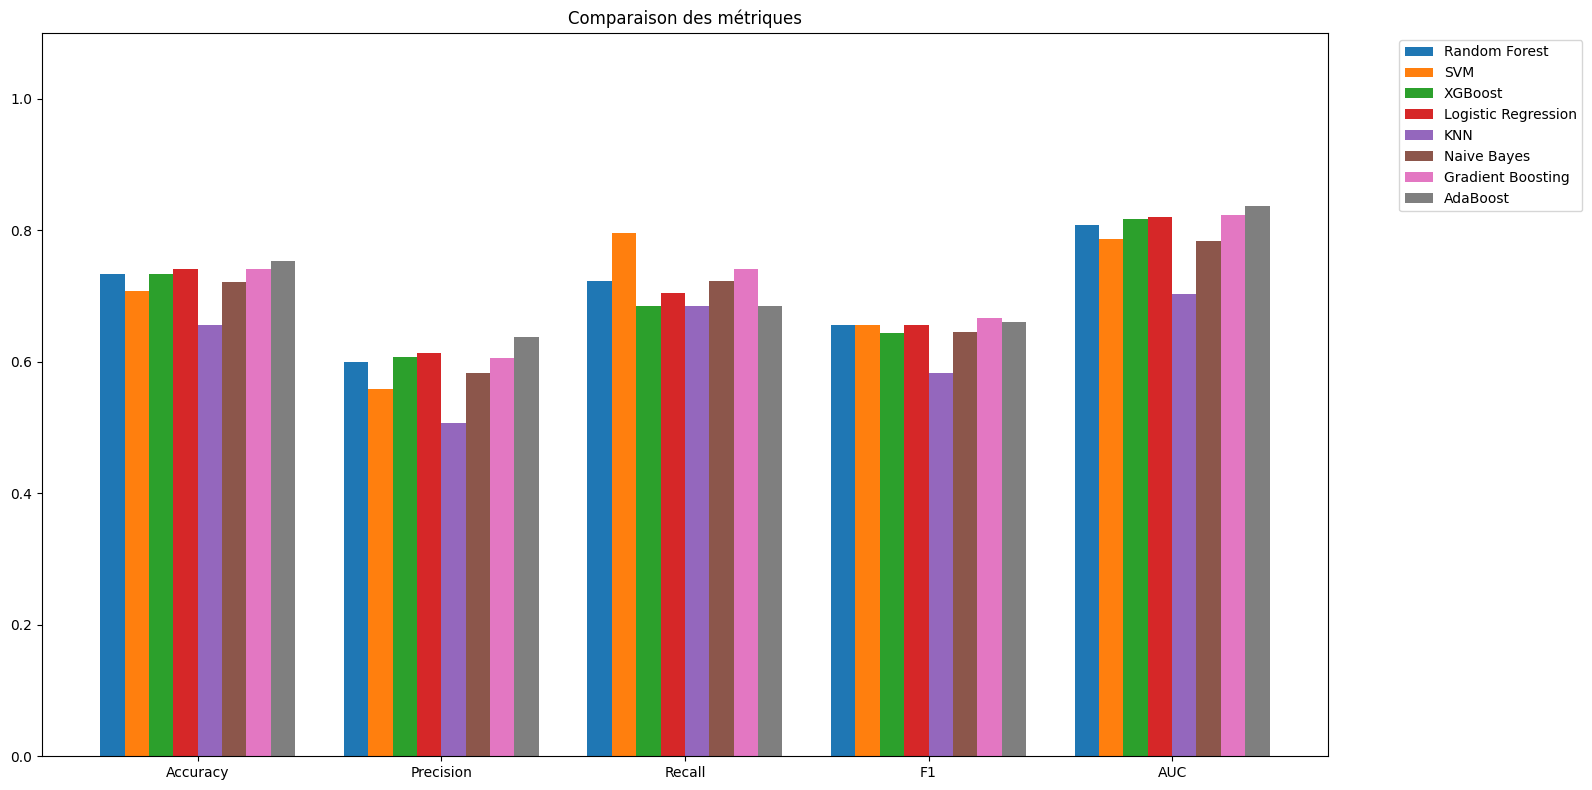

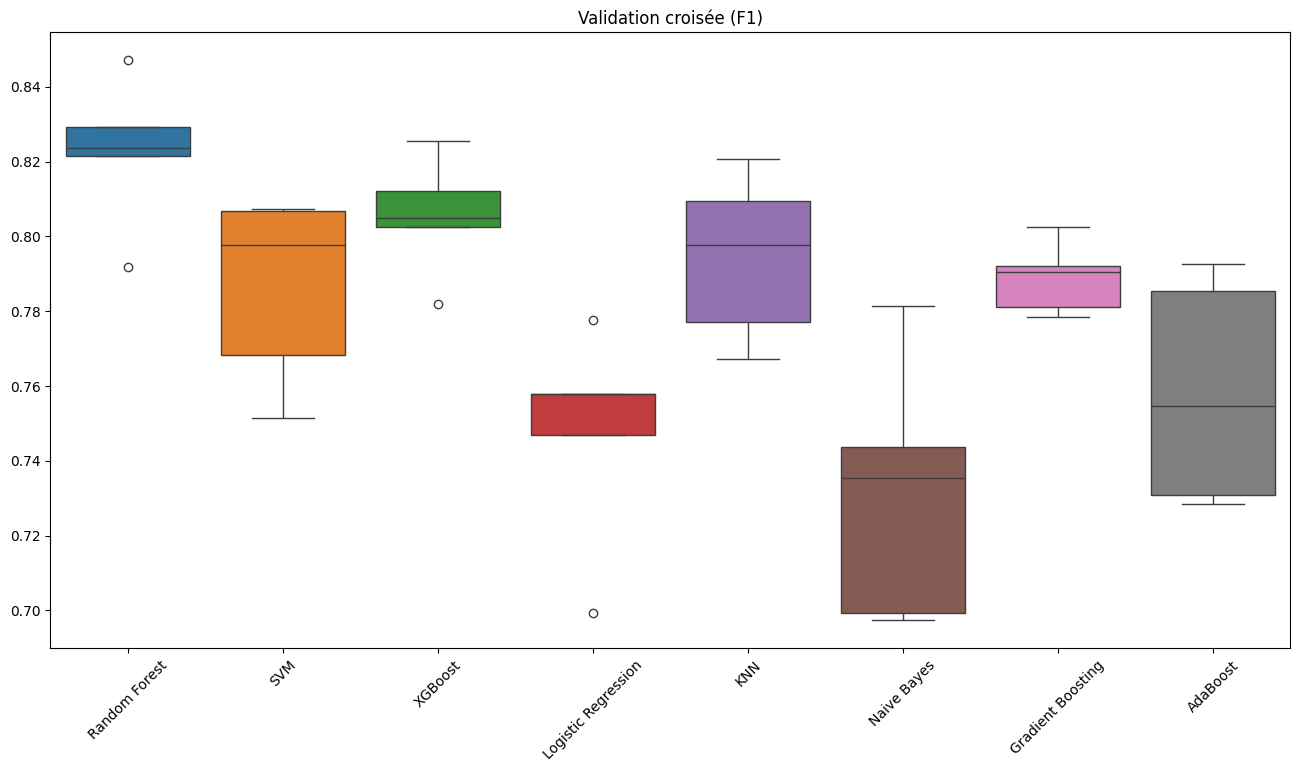

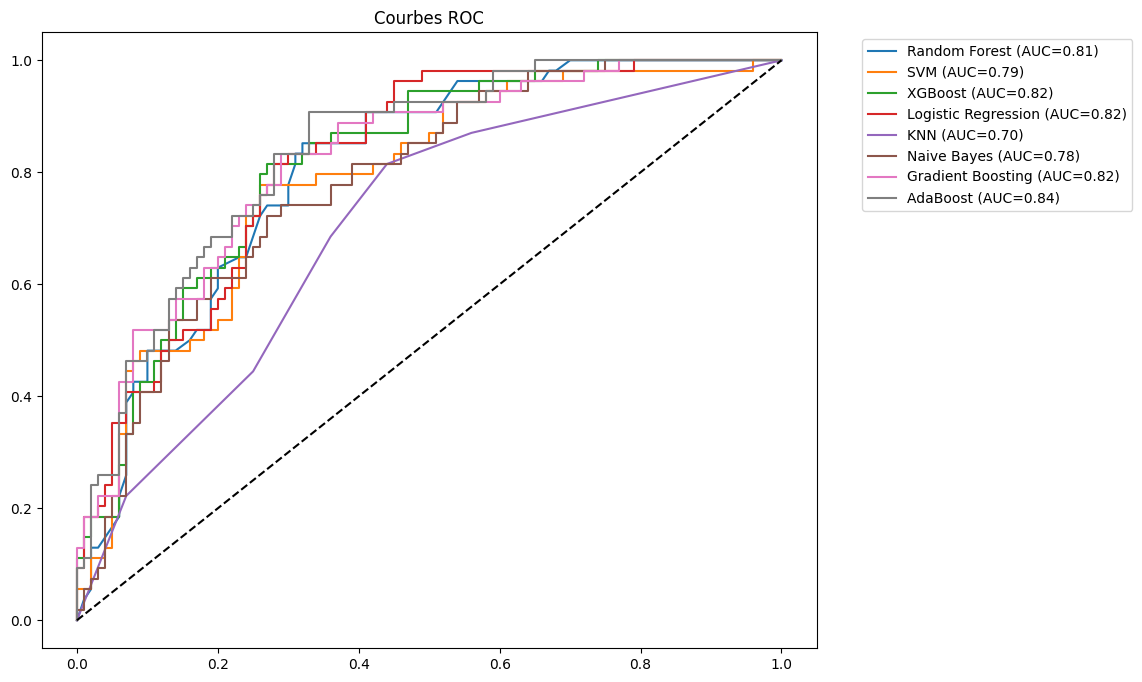

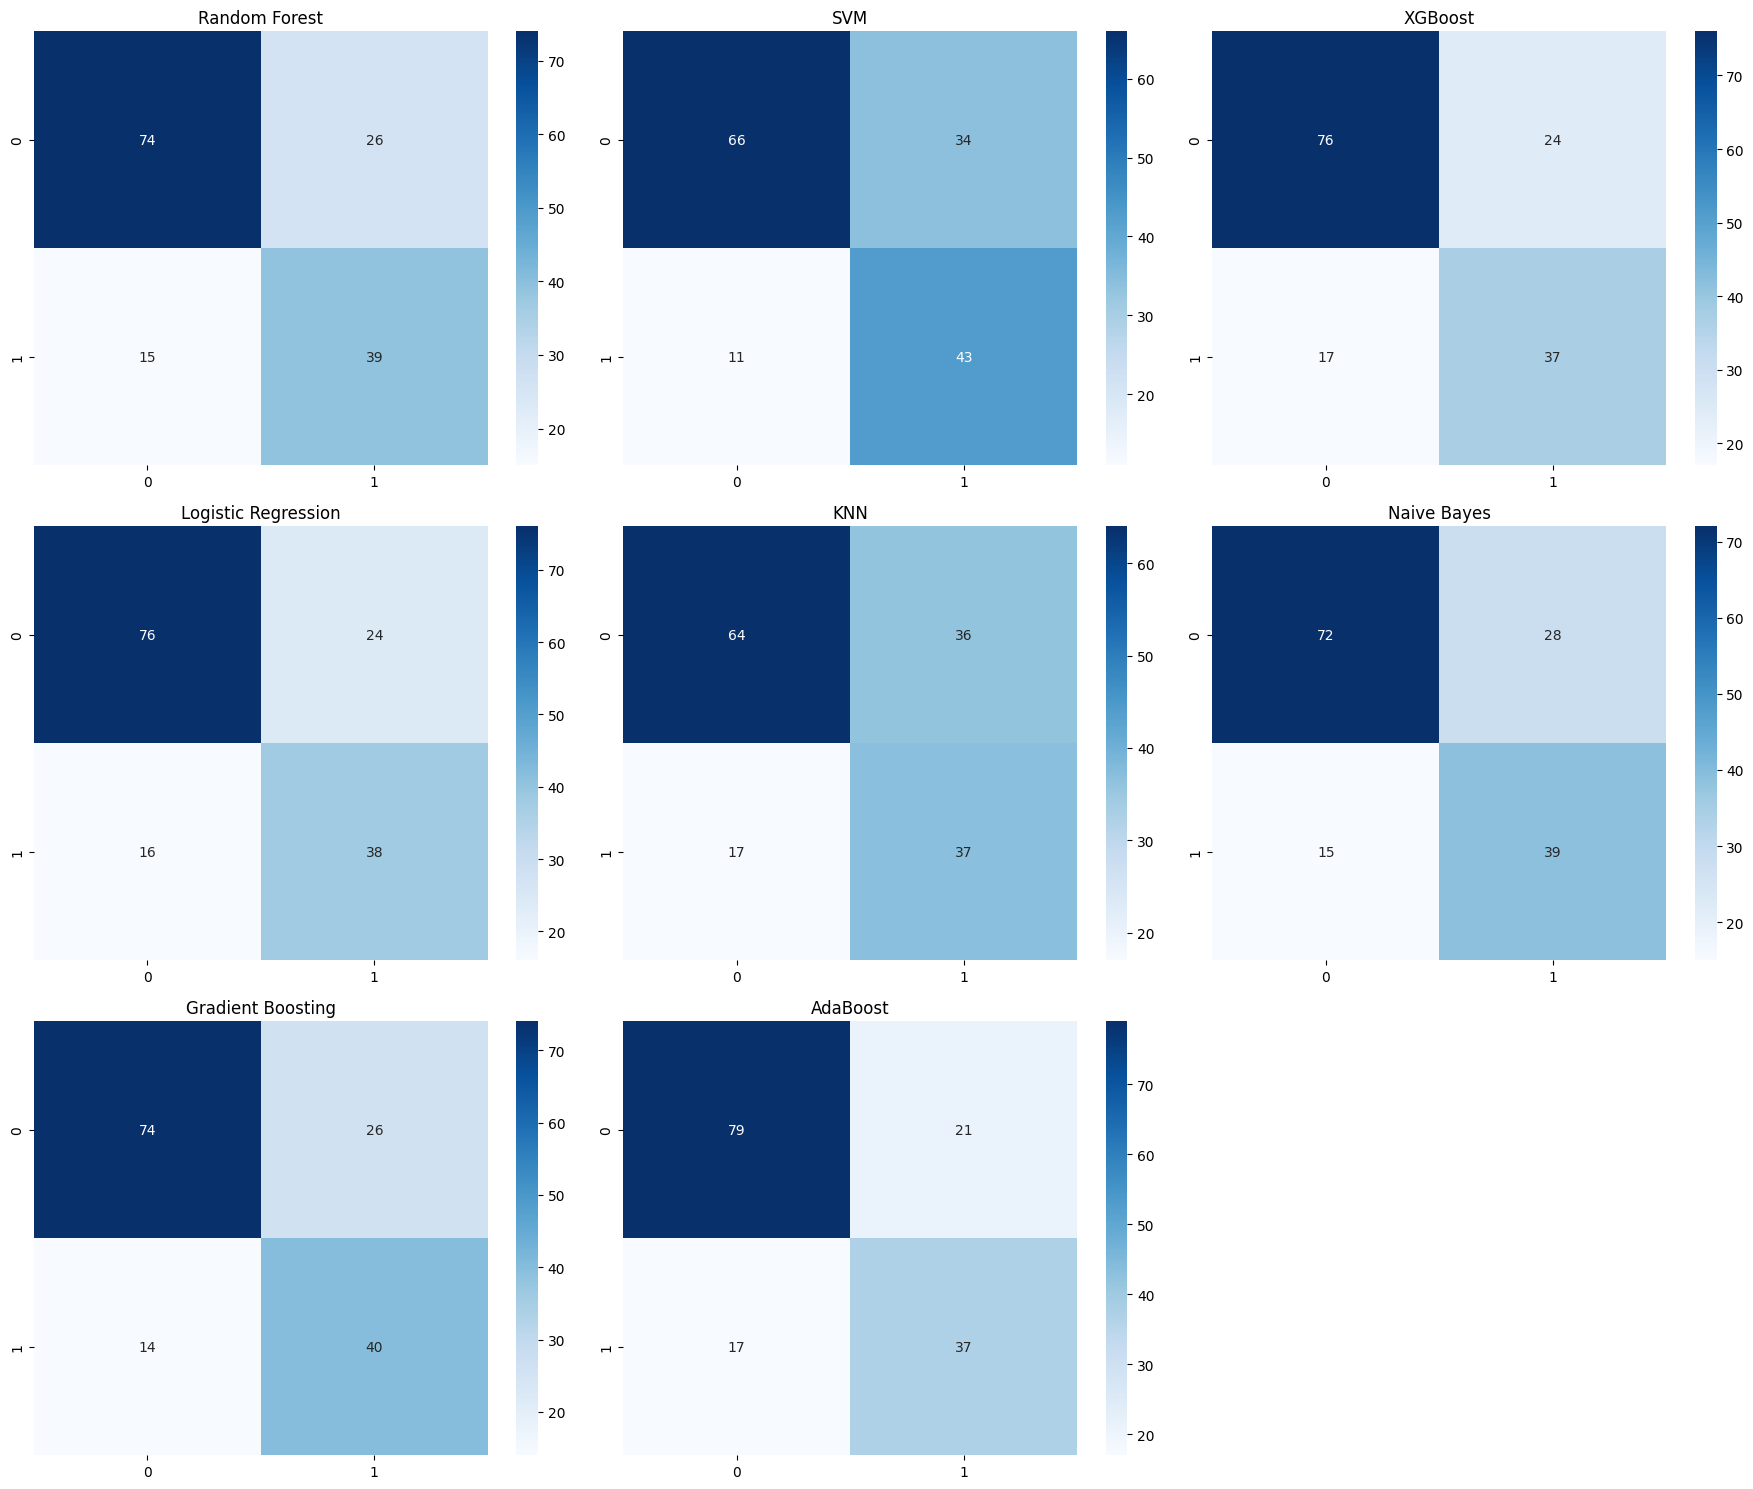

In [ ]:
import math

model_names = list(results.keys())
n_models = len(model_names)
n_cols = 3

# ── FIGURE 1 : métriques ──
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
x = np.arange(len(metrics))
width = 0.8 / n_models

plt.figure(figsize=(16, 8))

for i, name in enumerate(model_names):
    vals = [results[name][m] for m in metrics]
    plt.bar(x + i * width, vals, width, label=name)

plt.xticks(x + width * (n_models - 1) / 2, metrics)
plt.ylim(0, 1.1)
plt.title("Comparaison des métriques")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


# ── FIGURE 2 : boxplot CV ──
plt.figure(figsize=(16, 8))
sns.boxplot(data=pd.DataFrame(cv_results))
plt.title("Validation croisée (F1)")
plt.xticks(rotation=45)
plt.show()


# ── FIGURE 3 : ROC ──
plt.figure(figsize=(10, 8))

for name in model_names:
    if results[name]["y_prob"] is not None:
        fpr, tpr, _ = roc_curve(y_test, results[name]["y_prob"])
        auc = results[name]["AUC"]
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Courbes ROC")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()


# ── FIGURE 4 : matrices de confusion ──
n_cols = 3
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, name in enumerate(model_names):
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(name)

# cacher cases vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
print("=== RAPPORT DÉTAILLÉ PAR MODÈLE ===\n")

for name in results.keys():
    print(f"{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(
        y_test,
        results[name]["y_pred"],
        target_names=["Not Diabetic", "Diabetic"]
    ))

=== RAPPORT DÉTAILLÉ PAR MODÈLE ===

  Random Forest
              precision    recall  f1-score   support

Not Diabetic       0.83      0.74      0.78       100
    Diabetic       0.60      0.72      0.66        54

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154

  SVM
              precision    recall  f1-score   support

Not Diabetic       0.86      0.66      0.75       100
    Diabetic       0.56      0.80      0.66        54

    accuracy                           0.71       154
   macro avg       0.71      0.73      0.70       154
weighted avg       0.75      0.71      0.71       154

  XGBoost
              precision    recall  f1-score   support

Not Diabetic       0.82      0.76      0.79       100
    Diabetic       0.61      0.69      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.72       154
weigh

# LLM

## Zero_shot

In [ ]:
!pip install mistralai groq google-generativeai mistralai -q
!pip install mistralai
print("Installations OK")

In [ ]:
from google.colab import userdata

MISTRAL_API_KEY = userdata.get('Mistral_api_key')
GROQ_API_KEY    = userdata.get('Groq_api_key')
GEMINI_API_KEY  = userdata.get('Gemini_API_Key')

print("Clés chargées")

Clés chargées


In [ ]:
import pandas as pd

data_zero_url = "https://raw.githubusercontent.com/touXik/LLM-vs-ML-projet-nlp-/main/data/test_zeroshot.csv"


In [ ]:


test = pd.read_csv(data_zero_url)

print(f"Nombre de patients : {len(test)}")
print(f"\nExemple de texte :\n{test['text'].iloc[0]}")
print(f"\nVraie réponse : {test['label'].iloc[0]}")

Nombre de patients : 154

Exemple de texte :
The patient is 40 years old. She had 7 pregnancies. Her glucose level is 159.0. Her blood pressure is 64.0. Her skin thickness is 0.0. Her insulin level is 0.0. Her BMI is 27.4. Her diabetes pedigree function is 0.294. Is this patient diabetic or not diabetic?

Vraie réponse : 0


In [ ]:
import time
from mistralai import Mistral
import groq
import google.generativeai as genai

# ── Mistral ──
def call_mistral(text, model="open-mistral-7b"):
    client = Mistral(api_key=MISTRAL_API_KEY)
    prompt = f"{text}\nAnswer with only 'diabetic' or 'not diabetic'."
    response = client.chat.complete(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.1,
        max_tokens=10
    )
    return response.choices[0].message.content.strip().lower()

# ── Groq (Llama3) ──
def call_groq(text, model="llama-3.1-8b-instant"):
    client = groq.Groq(api_key=GROQ_API_KEY)
    prompt = f"{text}\nAnswer with only 'diabetic' or 'not diabetic'."
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.1,
        max_tokens=10
    )
    return response.choices[0].message.content.strip().lower()

# ── Gemini ──
# def call_gemini(text, model="gemini-2.0-flash"):
#     genai.configure(api_key=GEMINI_API_KEY)
#     prompt = f"{text}\nAnswer with only 'diabetic' or 'not diabetic'."
#     m = genai.GenerativeModel(model)
#     response = m.generate_content(
#          prompt,
#        generation_config={"temperature": 0.1, "max_output_tokens": 10}
#     )
#     return response.text.strip().lower()

print("Fonctions définies")

Fonctions définies


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
def parse_response(response):
    """Convertit la réponse texte en 0 ou 1"""
    response = response.lower().strip()
    if "not diabetic" in response:
        return 0
    elif "diabetic" in response:
        return 1
    else:
        return -1  # réponse non reconnue

print("Parser défini")

Parser défini


In [ ]:
from tqdm import tqdm

# Définition des modèles à tester
llm_models = {

    # ── Mistral ──
    "Mistral-Nemo"        : lambda text: call_mistral(text, "open-mistral-nemo"),
    "Mistral-Small"       : lambda text: call_mistral(text, "mistral-small-latest"),

    # Groq
    "Llama3.1-8B"   : lambda text: call_groq(text, "llama-3.1-8b-instant"),
    "Llama3.3-70B"  : lambda text: call_groq(text, "llama-3.3-70b-versatile"),

    #  # ── Gemini (Google) ──
    # "Gemini-2.0-Flash"      : lambda text: call_gemini(text, "gemini-2.0-flash"),
    # "Gemini-2.5-Flash"      : lambda text: call_gemini(text, "gemini-2.5-flash"),
    # "Gemini-2.5-Pro"        : lambda text: call_gemini(text, "gemini-2.5-pro"),
}

llm_predictions = {}

for model_name, call_fn in llm_models.items():
    print(f"\n Test de {model_name}...")
    preds = []
    errors = 0

    for i, row in tqdm(test.iterrows(), total=len(test)):
        try:
            response = call_fn(row["text"])
            pred = parse_response(response)
            preds.append(pred)
        except Exception as e:
            print(f" Erreur patient {i} : {e}")
            preds.append(-1)
            errors += 1

        time.sleep(0.5)  # éviter de dépasser les limites API

    llm_predictions[model_name] = preds
    valid = sum(1 for p in preds if p != -1)
    print(f"{model_name} terminé | Valides: {valid}/154 | Erreurs: {errors}")


 Test de Mistral-Nemo...


 67%|██████▋   | 103/154 [01:43<00:50,  1.01it/s]

 Erreur patient 103 : API error occurred: Status 429
{"object":"error","message":"Rate limit exceeded","type":"rate_limited","param":null,"code":"1300","raw_status_code":429}


100%|██████████| 154/154 [02:38<00:00,  1.03s/it]


Mistral-Nemo terminé | Valides: 153/154 | Erreurs: 1

 Test de Mistral-Small...


...

Mistral-Small terminé | Valides: 154/154 | Erreurs: 0

 Test de Llama3.1-8B...


100%|██████████| 154/154 [06:04<00:00,  2.37s/it]


Llama3.1-8B terminé | Valides: 154/154 | Erreurs: 0

 Test de Llama3.3-70B...


100%|██████████| 154/154 [06:08<00:00,  2.39s/it]

Llama3.3-70B terminé | Valides: 154/154 | Erreurs: 0


In [ ]:
# Voir les 10 premières prédictions pour TOUS les modèles
model_names = list(llm_predictions.keys())

# Header dynamique
header = f"{'Patient':<10} {'Vraie réponse':<20}"
for name in model_names:
    header += f" {name:<25}"
print("=== ÉCHANTILLON DES PRÉDICTIONS ===\n")
print(header)
print("-" * (30 + 25 * len(model_names)))

for i in range(10):
    vrai = "diabetic" if test["label"].iloc[i] == 1 else "not diabetic"
    row_str = f"{i:<10} {vrai:<20}"

    for name in model_names:
        pred = llm_predictions[name][i]
        pred_text = "diabetic" if pred == 1 else "not diabetic" if pred == 0 else " ? inconnu"
        correct = "True" if pred == test["label"].iloc[i] else "False"
        row_str += f" {correct} {pred_text:<23}"

    print(row_str)

=== ÉCHANTILLON DES PRÉDICTIONS ===

Patient    Vraie réponse        Mistral-Nemo              Mistral-Small             Llama3.1-8B               Llama3.3-70B             
----------------------------------------------------------------------------------------------------------------------------------
0          not diabetic         True not diabetic            False diabetic                False diabetic                True not diabetic           
1          not diabetic         True not diabetic            False diabetic                True not diabetic            True not diabetic           
2          not diabetic         True not diabetic            False diabetic                False diabetic                False diabetic               
3          diabetic             False not diabetic            True diabetic                False not diabetic            False not diabetic           
4          not diabetic         True not diabetic            True not diabetic            True 

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

y_true = test["label"].values
llm_results = {}

print("=== RÉSULTATS ZERO-SHOT ===\n")

for model_name, preds in llm_predictions.items():
    # Filtrer les réponses non reconnues
    valid_idx = [i for i, p in enumerate(preds) if p != -1]
    y_true_valid = y_true[valid_idx]
    y_pred_valid = [preds[i] for i in valid_idx]

    if len(y_pred_valid) == 0:
        print(f"{model_name} : aucune prédiction valide\n")
        continue

    llm_results[model_name] = {
        "Accuracy"  : accuracy_score(y_true_valid, y_pred_valid),
        "Precision" : precision_score(y_true_valid, y_pred_valid, zero_division=0),
        "Recall"    : recall_score(y_true_valid, y_pred_valid, zero_division=0),
        "F1"        : f1_score(y_true_valid, y_pred_valid, zero_division=0),
        "y_pred"    : y_pred_valid,
        "y_true"    : y_true_valid,
        "valid"     : len(valid_idx)
    }

    print(f"{model_name} ({len(valid_idx)}/154 valides)")
    print(f"  Accuracy  : {llm_results[model_name]['Accuracy']:.3f}")
    print(f"  Precision : {llm_results[model_name]['Precision']:.3f}")
    print(f"  Recall    : {llm_results[model_name]['Recall']:.3f}")
    print(f"  F1        : {llm_results[model_name]['F1']:.3f}\n")

=== RÉSULTATS ZERO-SHOT ===

Mistral-Nemo (153/154 valides)
  Accuracy  : 0.654
  Precision : 1.000
  Recall    : 0.019
  F1        : 0.036

Mistral-Small (154/154 valides)
  Accuracy  : 0.630
  Precision : 0.485
  Recall    : 0.926
  F1        : 0.637

Llama3.1-8B (154/154 valides)
  Accuracy  : 0.688
  Precision : 0.545
  Recall    : 0.667
  F1        : 0.600

Llama3.3-70B (154/154 valides)
  Accuracy  : 0.688
  Precision : 0.543
  Recall    : 0.704
  F1        : 0.613



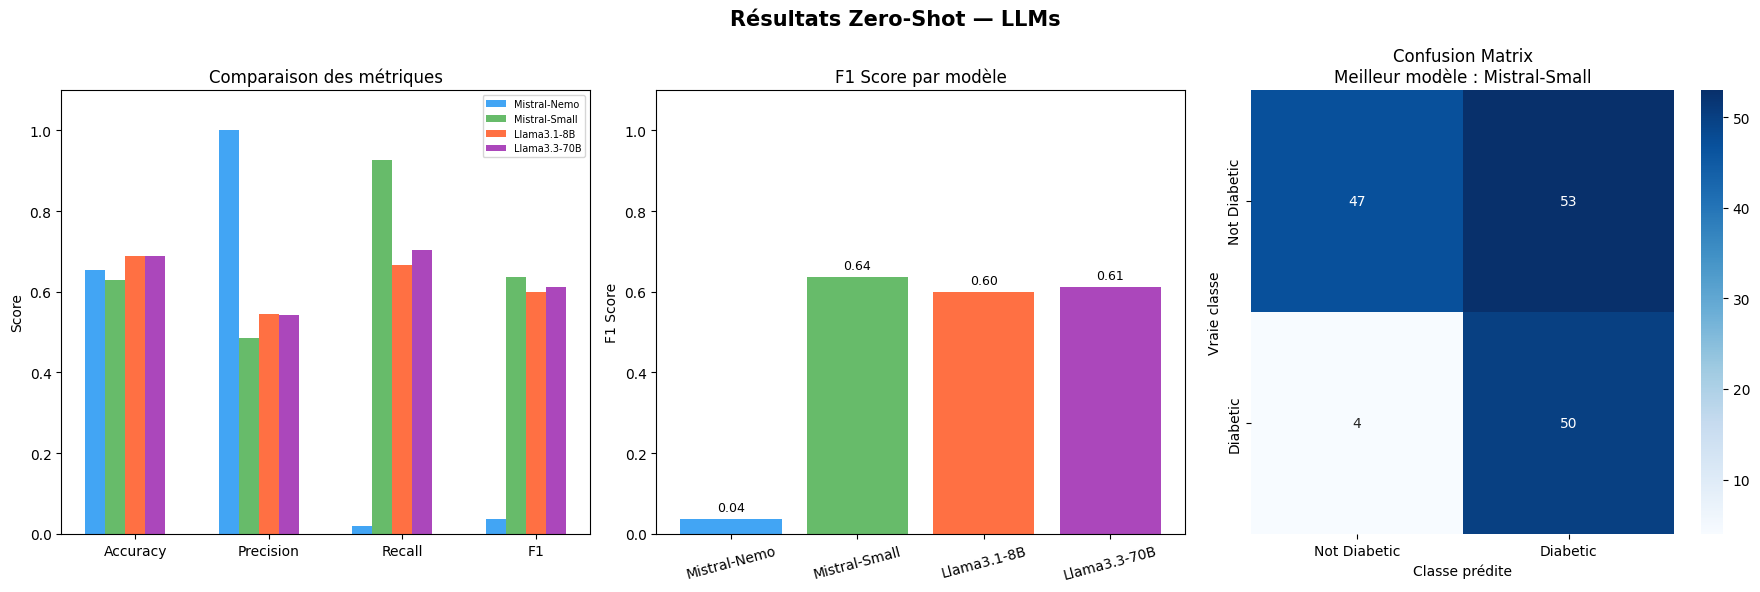


 Meilleur modèle Zero-Shot : Mistral-Small


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Résultats Zero-Shot — LLMs", fontsize=15, fontweight='bold')

model_names = list(llm_results.keys())
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']
metrics = ["Accuracy", "Precision", "Recall", "F1"]

# ── Graphique 1 : Comparaison métriques ──
ax1 = axes[0]
x = np.arange(len(metrics))
width = 0.15
for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [llm_results[name][m] for m in metrics]
    ax1.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)
ax1.set_xticks(x + width * 2)
ax1.set_xticklabels(metrics)
ax1.set_ylim(0, 1.1)
ax1.set_title("Comparaison des métriques")
ax1.legend(fontsize=7)
ax1.set_ylabel("Score")

# ── Graphique 2 : F1 Score comparaison ──
ax2 = axes[1]
f1_scores = [llm_results[n]["F1"] for n in model_names]
bars = ax2.bar(model_names, f1_scores, color=colors[:len(model_names)], alpha=0.85)
ax2.set_ylim(0, 1.1)
ax2.set_title("F1 Score par modèle")
ax2.set_ylabel("F1 Score")
for bar, val in zip(bars, f1_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.2f}", ha='center', fontsize=9)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=15)

# ── Graphique 3 : Matrice confusion meilleur modèle ──
ax3 = axes[2]
best_model = max(llm_results, key=lambda n: llm_results[n]["F1"])
cm = confusion_matrix(llm_results[best_model]["y_true"],
                      llm_results[best_model]["y_pred"])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=["Not Diabetic", "Diabetic"],
            yticklabels=["Not Diabetic", "Diabetic"])
ax3.set_title(f"Confusion Matrix\nMeilleur modèle : {best_model}")
ax3.set_ylabel("Vraie classe")
ax3.set_xlabel("Classe prédite")

plt.tight_layout()
plt.savefig("resultats_zeroshot.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n Meilleur modèle Zero-Shot : {best_model}")

In [ ]:
# Sauvegarder les prédictions
df_preds = test.copy()
for model_name, preds in llm_predictions.items():
    df_preds[model_name] = preds

df_preds.to_csv("predictions_zeroshot.csv", index=False)

# Sauvegarder les métriques
df_metrics = pd.DataFrame(llm_results).T[["Accuracy", "Precision", "Recall", "F1"]]
df_metrics.to_csv("metrics_zeroshot.csv")

print(" Résultats sauvegardés !")
print(df_metrics.round(3))

 Résultats sauvegardés !
               Accuracy Precision    Recall        F1
Mistral-Nemo   0.653595       1.0  0.018519  0.036364
Mistral-Small   0.62987  0.485437  0.925926  0.636943
Llama3.1-8B    0.688312  0.545455  0.666667       0.6
Llama3.3-70B   0.688312  0.542857  0.703704  0.612903


# **FINETUNING**

In [ ]:
# ==============================================================
# DistilBERT + LoRA + Oversampling + Focal Loss
# Classification texte médical (diabète)
# ==============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from peft import get_peft_model, LoraConfig, TaskType
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

# ──────────────────────────────────────────────
# 1. CONFIG
# ──────────────────────────────────────────────
MODEL_NAME = "distilbert-base-uncased"
TRAIN_CSV = "train_finetune.csv"
TEST_CSV  = "test_finetune.csv"
OUTPUT_DIR = "./lora_diabetes_focal"

MAX_LENGTH = 128
BATCH_SIZE = 16
NUM_EPOCHS = 6
LR = 3e-5
SEED = 42
VAL_SIZE = 0.2

# LoRA
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.2
LORA_TARGETS = ["q_lin", "v_lin"]

DEVICE = "cpu" if os.environ.get("USE_CPU") else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Appareil utilisé : {DEVICE.upper()}")

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ──────────────────────────────────────────────
# 2. CHARGEMENT DES DONNÉES
# ──────────────────────────────────────────────
print("\n📂 Chargement des données...")
train_full_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

required_cols = {"text", "label"}
if not required_cols.issubset(train_full_df.columns):
    raise ValueError(f"{TRAIN_CSV} doit contenir les colonnes : {required_cols}")
if not required_cols.issubset(test_df.columns):
    raise ValueError(f"{TEST_CSV} doit contenir les colonnes : {required_cols}")

train_df, val_df = train_test_split(
    train_full_df,
    test_size=VAL_SIZE,
    stratify=train_full_df["label"],
    random_state=SEED
)

print(f"   Train full : {len(train_full_df)} exemples")
print(f"   Train      : {len(train_df)} exemples  | label 0: {(train_df.label==0).sum()} | label 1: {(train_df.label==1).sum()}")
print(f"   Validation : {len(val_df)} exemples  | label 0: {(val_df.label==0).sum()} | label 1: {(val_df.label==1).sum()}")
print(f"   Test       : {len(test_df)} exemples  | label 0: {(test_df.label==0).sum()} | label 1: {(test_df.label==1).sum()}")

# ──────────────────────────────────────────────
# 3. OVERSAMPLING DU TRAIN
# ──────────────────────────────────────────────
print("\n⚖️  Oversampling du jeu d'entraînement...")

train_major = train_df[train_df["label"] == 0]
train_minor = train_df[train_df["label"] == 1]

if len(train_major) > len(train_minor):
    train_minor_up = train_minor.sample(n=len(train_major), replace=True, random_state=SEED)
    train_balanced_df = pd.concat([train_major, train_minor_up], axis=0)
else:
    train_major_up = train_major.sample(n=len(train_minor), replace=True, random_state=SEED)
    train_balanced_df = pd.concat([train_major_up, train_minor], axis=0)

train_balanced_df = train_balanced_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"   Après oversampling :")
print(train_balanced_df["label"].value_counts())

# ──────────────────────────────────────────────
# 4. TOKENIZER & DATASET
# ──────────────────────────────────────────────
print(f"\n🔤 Chargement du tokenizer ({MODEL_NAME})...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class MedicalDataset(Dataset):
    def __init__(self, df, tokenizer, max_length):
        self.texts = df["text"].astype(str).tolist()
        self.labels = df["label"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding=False
        )
        enc["labels"] = self.labels[idx]
        return enc

train_dataset = MedicalDataset(train_balanced_df, tokenizer, MAX_LENGTH)
val_dataset   = MedicalDataset(val_df, tokenizer, MAX_LENGTH)
test_dataset  = MedicalDataset(test_df, tokenizer, MAX_LENGTH)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ──────────────────────────────────────────────
# 5. MODÈLE + LoRA
# ──────────────────────────────────────────────
print(f"\n🧠 Chargement du modèle de base ({MODEL_NAME})...")
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "Non diabétique", 1: "Diabétique"},
    label2id={"Non diabétique": 0, "Diabétique": 1},
)

total_params = sum(p.numel() for p in base_model.parameters())
print(f"   Paramètres totaux : {total_params:,}")

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGETS,
    bias="none",
    modules_to_save=["classifier", "pre_classifier"],  # important
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

# ──────────────────────────────────────────────
# 6. FOCAL LOSS
# ──────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

focal_loss_fn = FocalLoss(alpha=1.0, gamma=2.0)

class FocalTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = focal_loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# ──────────────────────────────────────────────
# 7. MÉTRIQUES
# ──────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    preds = (probs >= 0.5).astype(int)

    out = {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
        "precision_pos": precision_score(labels, preds, zero_division=0),
        "recall_pos": recall_score(labels, preds, zero_division=0),
    }

    try:
        out["auc"] = roc_auc_score(labels, probs)
    except:
        out["auc"] = 0.0

    return out

# ──────────────────────────────────────────────
# 8. TRAINING ARGUMENTS
# ──────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=20,
    save_total_limit=2,
    fp16=(DEVICE == "cuda"),
    report_to="none",
    seed=SEED,
)

# ──────────────────────────────────────────────
# 9. TRAINER
# ──────────────────────────────────────────────
trainer = FocalTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# ──────────────────────────────────────────────
# 10. ENTRAÎNEMENT
# ──────────────────────────────────────────────
print("\n🚀 Début de l'entraînement...\n")
trainer.train()
print("\n✅ Entraînement terminé !")

# ──────────────────────────────────────────────
# 11. CHOIX DU MEILLEUR SEUIL SUR VALIDATION
# ──────────────────────────────────────────────
def find_best_threshold(y_true, y_prob):
    best_threshold = 0.5
    best_f1 = -1
    rows = []

    for t in np.arange(0.10, 0.91, 0.05):
        y_pred = (y_prob >= t).astype(int)
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        rows.append([round(t, 2), round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4)])

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

    return best_threshold, pd.DataFrame(rows, columns=["Threshold", "Accuracy", "Precision", "Recall", "F1"])

print("\n🎯 Recherche du meilleur seuil sur validation...")
val_out = trainer.predict(val_dataset)
y_val_true = val_df["label"].astype(int).values
y_val_prob = torch.softmax(torch.tensor(val_out.predictions), dim=-1)[:, 1].numpy()

best_threshold, th_df = find_best_threshold(y_val_true, y_val_prob)
print(th_df.to_string(index=False))
print(f"\n✅ Meilleur seuil = {best_threshold:.2f}")

# ──────────────────────────────────────────────
# 12. ÉVALUATION FINALE TEST
# ──────────────────────────────────────────────
print("\n📊 Évaluation finale sur le test...")
test_out = trainer.predict(test_dataset)
y_test_true = test_df["label"].astype(int).values
y_test_prob = torch.softmax(torch.tensor(test_out.predictions), dim=-1)[:, 1].numpy()
y_test_pred = (y_test_prob >= best_threshold).astype(int)

acc = accuracy_score(y_test_true, y_test_pred)
prec = precision_score(y_test_true, y_test_pred, zero_division=0)
rec = recall_score(y_test_true, y_test_pred, zero_division=0)
f1 = f1_score(y_test_true, y_test_pred, zero_division=0)
f1_macro = f1_score(y_test_true, y_test_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_test_true, y_test_pred, average="weighted", zero_division=0)

try:
    auc = roc_auc_score(y_test_true, y_test_prob)
except:
    auc = 0.0

print(f"   Accuracy    : {acc:.4f}")
print(f"   Precision   : {prec:.4f}")
print(f"   Recall      : {rec:.4f}")
print(f"   F1          : {f1:.4f}")
print(f"   F1 macro    : {f1_macro:.4f}")
print(f"   F1 weighted : {f1_weighted:.4f}")
print(f"   AUC-ROC     : {auc:.4f}")

print("\n📋 Rapport de classification TEST :")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=["Non diabétique", "Diabétique"],
    zero_division=0
))

print("🧩 Matrice de confusion TEST :")
print(confusion_matrix(y_test_true, y_test_pred))

# ──────────────────────────────────────────────
# 13. TABLEAU FINAL
# ──────────────────────────────────────────────
results_df = pd.DataFrame([{
    "Model": "DistilBERT + LoRA + FocalLoss",
    "Threshold": round(float(best_threshold), 2),
    "Accuracy": round(float(acc), 4),
    "Precision": round(float(prec), 4),
    "Recall": round(float(rec), 4),
    "F1": round(float(f1), 4),
    "F1_macro": round(float(f1_macro), 4),
    "AUC_ROC": round(float(auc), 4),
}])

print("\n📌 Tableau final :")
print(results_df.to_string(index=False))

# ──────────────────────────────────────────────
# 14. SAUVEGARDE
# ──────────────────────────────────────────────
print(f"\n💾 Sauvegarde dans {OUTPUT_DIR} ...")
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print("   Modèle sauvegardé.")

# ──────────────────────────────────────────────
# 15. INFÉRENCE
# ──────────────────────────────────────────────
EXAMPLE_TEXT = (
    "The patient is 45 years old. She had 3 pregnancies. "
    "Her glucose level is 150.0. Her blood pressure is 90.0. "
    "Her skin thickness is 35.0. Her insulin level is 180.0. "
    "Her BMI is 33.5. Her diabetes pedigree function is 0.627."
)

def predict(text, model, tokenizer, threshold=0.5, max_length=128):
    model.eval()
    model.to(DEVICE)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
        padding=True,
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1).squeeze().tolist()
    p1 = probs[1]
    pred = 1 if p1 >= threshold else 0

    return {
        "label": "Diabétique" if pred == 1 else "Non diabétique",
        "prob_non_diab": probs[0],
        "prob_diab": probs[1],
    }

pred = predict(EXAMPLE_TEXT, model, tokenizer, threshold=best_threshold, max_length=MAX_LENGTH)
print("\n🔮 Exemple d'inférence :")
print(f"   Prédiction : {pred['label']}")
print(f"   P(Non diabétique) = {pred['prob_non_diab']:.4f}")
print(f"   P(Diabétique)     = {pred['prob_diab']:.4f}")

🖥️  Appareil utilisé : CPU

📂 Chargement des données...
   Train full : 614 exemples
   Train      : 491 exemples  | label 0: 320 | label 1: 171
   Validation : 123 exemples  | label 0: 80 | label 1: 43
   Test       : 154 exemples  | label 0: 100 | label 1: 54

⚖️  Oversampling du jeu d'entraînement...
   Après oversampling :
label
1    320
0    320
Name: count, dtype: int64

🔤 Chargement du tokenizer (distilbert-base-uncased)...

🧠 Chargement du modèle de base (distilbert-base-uncased)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Paramètres totaux : 66,955,010
trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925

🚀 Début de l'entraînement...



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Pos,Recall Pos,Auc
1,0.170347,0.172054,0.349593,0.259036,0.181115,0.349593,1.000000,1.000000
2,0.167607,0.175462,0.349593,0.259036,0.181115,0.349593,1.000000,1.000000
3,0.162300,0.151396,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,0.146646,0.132700,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,0.124818,0.106216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



✅ Entraînement terminé !

🎯 Recherche du meilleur seuil sur validation...


 Threshold  Accuracy  Precision  Recall     F1
      0.10    0.3496     0.3496     1.0 0.5181
      0.15    0.3496     0.3496     1.0 0.5181
      0.20    0.3496     0.3496     1.0 0.5181
      0.25    0.3496     0.3496     1.0 0.5181
      0.30    0.3496     0.3496     1.0 0.5181
      0.35    0.3496     0.3496     1.0 0.5181
      0.40    0.3496     0.3496     1.0 0.5181
      0.45    0.3496     0.3496     1.0 0.5181
      0.50    1.0000     1.0000     1.0 1.0000
      0.55    0.6504     0.0000     0.0 0.0000
      0.60    0.6504     0.0000     0.0 0.0000
      0.65    0.6504     0.0000     0.0 0.0000
      0.70    0.6504     0.0000     0.0 0.0000
      0.75    0.6504     0.0000     0.0 0.0000
      0.80    0.6504     0.0000     0.0 0.0000
      0.85    0.6504     0.0000     0.0 0.0000
      0.90    0.6504     0.0000     0.0 0.0000

✅ Meilleur seuil = 0.50

📊 Évaluation finale sur le test...


   Accuracy    : 0.4610
   Precision   : 0.3407
   Recall      : 0.5741
   F1          : 0.4276
   F1 macro    : 0.4592
   F1 weighted : 0.4686
   AUC-ROC     : 0.5056

📋 Rapport de classification TEST :
                precision    recall  f1-score   support

Non diabétique       0.63      0.40      0.49       100
    Diabétique       0.34      0.57      0.43        54

      accuracy                           0.46       154
     macro avg       0.49      0.49      0.46       154
  weighted avg       0.53      0.46      0.47       154

🧩 Matrice de confusion TEST :
[[40 60]
 [23 31]]

📌 Tableau final :
                        Model  Threshold  Accuracy  Precision  Recall     F1  F1_macro  AUC_ROC
DistilBERT + LoRA + FocalLoss        0.5     0.461     0.3407  0.5741 0.4276    0.4592   0.5056

💾 Sauvegarde dans ./lora_diabetes_focal ...
   Modèle sauvegardé.

🔮 Exemple d'inférence :
   Prédiction : Diabétique
   P(Non diabétique) = 0.4864
   P(Diabétique)     = 0.5136
